In [52]:
# ============================================================
#  imports and setup
# ============================================================
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# ============================================================
# load CSV once, create database, quick quality check
# ============================================================

# Load CSV — only time we touch it
df = pd.read_csv('/Users/tejas_borse/Downloads/Sample - Superstore.csv', encoding='latin1')

# Quick data quality check
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDate range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("\nCategories:", df['Category'].unique())
print("\nRegions:", df['Region'].unique())

# Create database and load data
conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)
print(f"\nDatabase ready. {len(df)} rows loaded into 'orders' table.")

# We never use df again after this cell
del df

Shape: (9994, 21)

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Date range: 1/1/2017 to 9/9/2017

Categories: ['Furniture' 'Office Supplies' 'Technology']

Regions: ['South' 'West' 'Central' 'East']

Database ready. 9994 rows loaded into 'orders' table.


    Region  total_revenue  total_profit  profit_margin_pct
0     West      725457.82     108418.45              14.94
1     East      678781.24      91522.78              13.48
2  Central      501239.89      39706.36               7.92
3    South      391721.91      46749.43              11.93


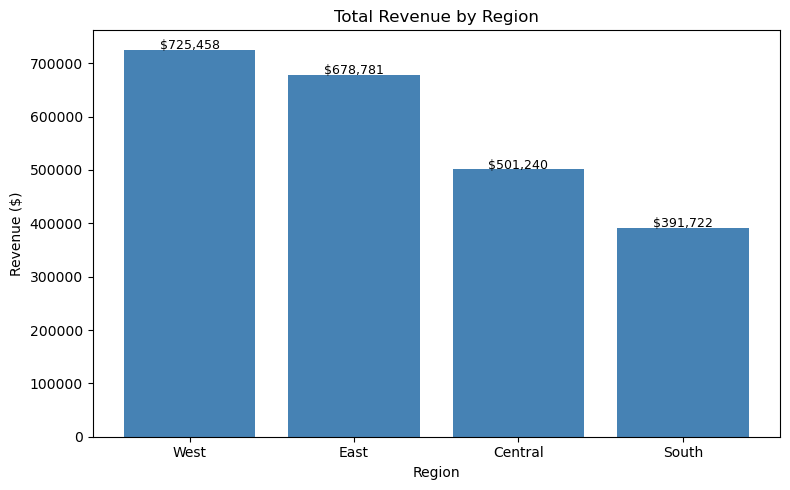

In [58]:
# ============================================================
# Business question 1
# Which region generates the most revenue and profit?
# ============================================================

result1 = pd.read_sql_query("""
    SELECT 
        Region,
        ROUND(SUM(Sales), 2)                        AS total_revenue,
        ROUND(SUM(Profit), 2)                       AS total_profit,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 2)   AS profit_margin_pct
    FROM orders
    GROUP BY Region
    ORDER BY total_revenue DESC
""", conn)

print(result1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(result1['Region'], result1['total_revenue'], color='steelblue')
ax.set_title('Total Revenue by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Revenue ($)')
for i, v in enumerate(result1['total_revenue']):
    ax.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('revenue_by_region.png', dpi=150)
plt.show()

       month  monthly_revenue
0    1/1/201          1481.83
1    1/10/20          1247.68
2    1/11/20           159.38
3    1/12/20          1703.13
4    1/13/20          8795.40
..       ...              ...
361  9/5/201          6783.80
362  9/6/201          2419.55
363  9/7/201         10295.11
364  9/8/201         20996.38
365  9/9/201          8484.64

[366 rows x 2 columns]


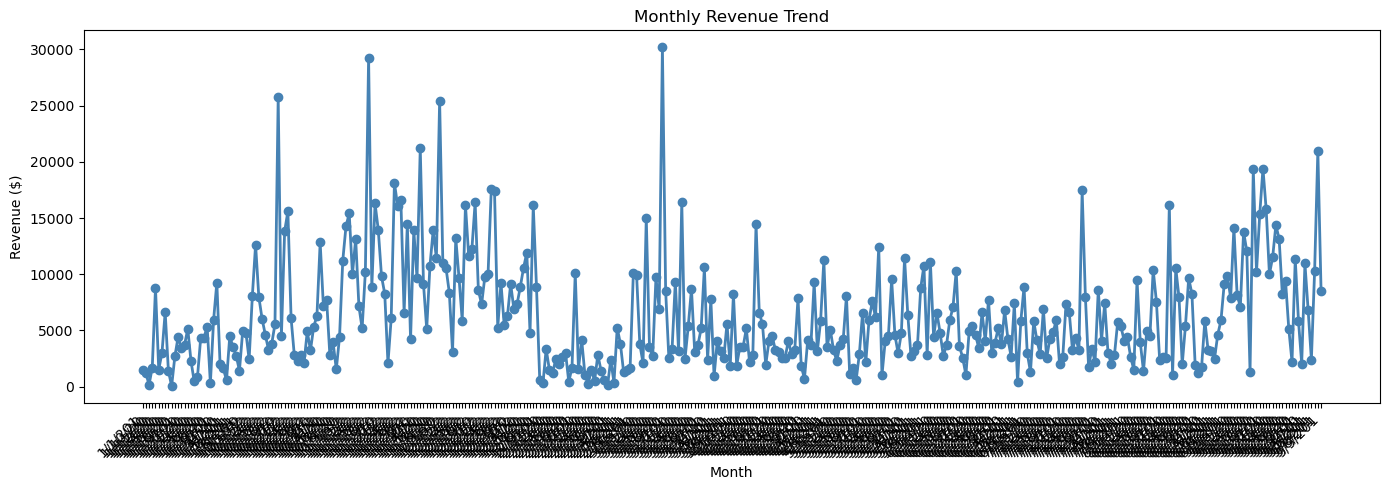

In [62]:
# ============================================================
# Business question 2
# What is the monthly revenue trend?
# ============================================================

result2 = pd.read_sql_query("""
    SELECT 
        substr("Order Date", 1, 7)      AS month,
        ROUND(SUM(Sales), 2)            AS monthly_revenue
    FROM orders
    GROUP BY month
    ORDER BY month
""", conn)

print(result2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(result2['month'], result2['monthly_revenue'],
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

          Category  total_sales  total_profit  profit_margin_pct
0       Technology    836154.03     145454.95              17.40
1  Office Supplies    719047.03     122490.80              17.04
2        Furniture    741999.80      18451.27               2.49


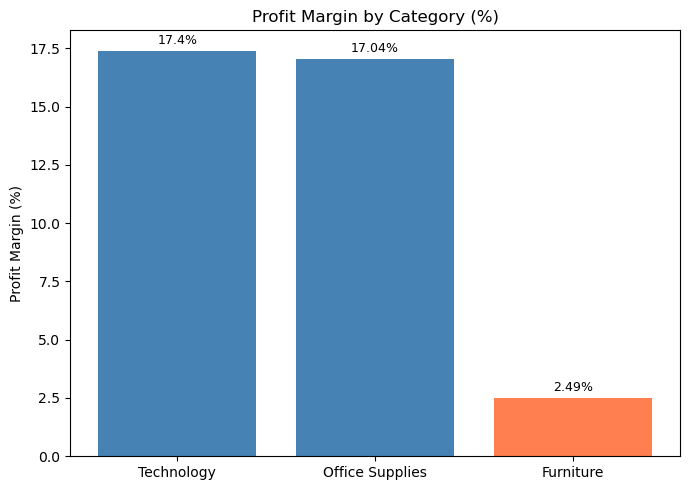

In [64]:
# ============================================================
# Business question 3
# Which category has the best profit margin?
# ============================================================

result3 = pd.read_sql_query("""
    SELECT 
        Category,
        ROUND(SUM(Sales), 2)                        AS total_sales,
        ROUND(SUM(Profit), 2)                       AS total_profit,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 2)   AS profit_margin_pct
    FROM orders
    GROUP BY Category
    ORDER BY profit_margin_pct DESC
""", conn)

print(result3)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue' if x > 10 else 'coral' for x in result3['profit_margin_pct']]
ax.bar(result3['Category'], result3['profit_margin_pct'], color=colors)
ax.set_title('Profit Margin by Category (%)')
ax.set_ylabel('Profit Margin (%)')
for i, v in enumerate(result3['profit_margin_pct']):
    ax.text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('profit_margin_category.png', dpi=150)
plt.show()

   discount_rate  avg_profit  order_count
0            0.0       66.90         4798
1            0.1       71.56          146
2            0.2       24.70         3657
3            0.3      -50.24          254
4            0.4     -111.93          206
5            0.5     -298.70           77
6            0.6      -43.08          138
7            0.7      -95.87          418
8            0.8     -101.80          300


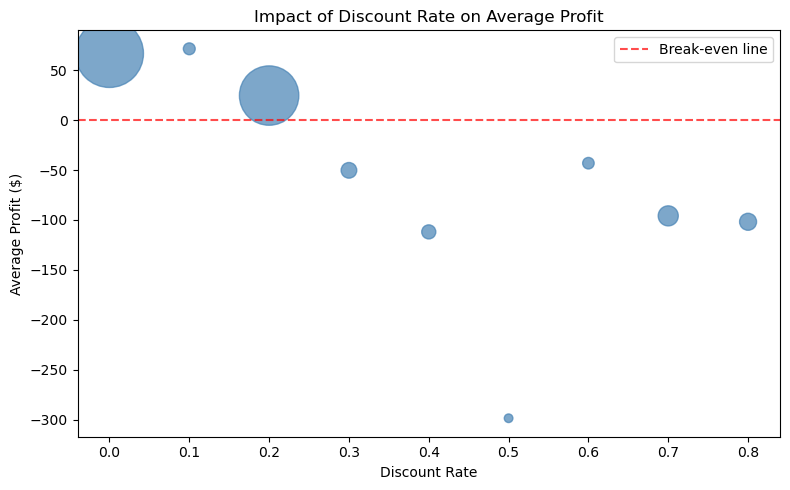

In [66]:
# ============================================================
# Business question 4
# At what discount level does profit turn negative?
# ============================================================

result4 = pd.read_sql_query("""
    SELECT 
        ROUND(Discount, 1)      AS discount_rate,
        ROUND(AVG(Profit), 2)   AS avg_profit,
        COUNT(*)                AS order_count
    FROM orders
    GROUP BY ROUND(Discount, 1)
    ORDER BY discount_rate
""", conn)

print(result4)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(result4['discount_rate'], result4['avg_profit'],
           s=result4['order_count'] * 0.5,
           color='steelblue', alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Break-even line')
ax.set_title('Impact of Discount Rate on Average Profit')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Average Profit ($)')
ax.legend()
plt.tight_layout()
plt.savefig('discount_profit.png', dpi=150)
plt.show()

  Sub-Category  total_profit  total_sales
0       Tables     -17725.48    206965.53
1    Bookcases      -3472.56    114880.00
2     Supplies      -1189.10     46673.54
3    Fasteners        949.52      3024.28
4     Machines       3384.76    189238.63


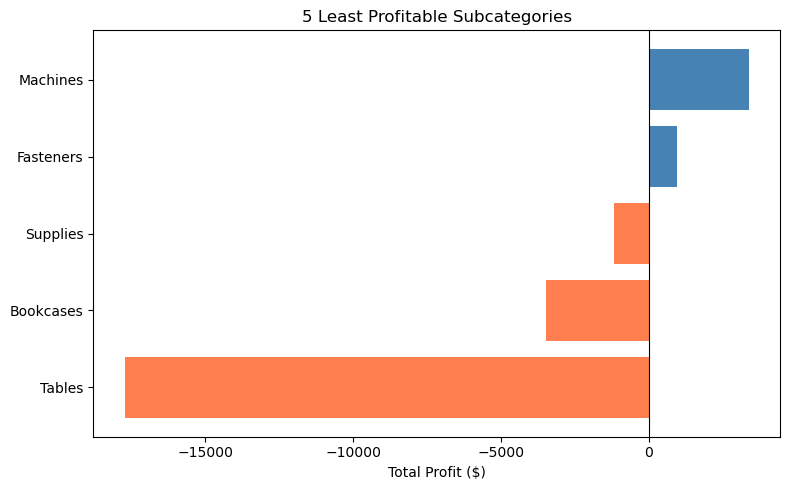

In [68]:
# ============================================================
# Business question 5
# Which subcategories are losing money?
# ============================================================

result5 = pd.read_sql_query("""
    SELECT 
        "Sub-Category",
        ROUND(SUM(Profit), 2)   AS total_profit,
        ROUND(SUM(Sales), 2)    AS total_sales
    FROM orders
    GROUP BY "Sub-Category"
    ORDER BY total_profit ASC
    LIMIT 5
""", conn)

print(result5)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['coral' if x < 0 else 'steelblue' for x in result5['total_profit']]
ax.barh(result5['Sub-Category'], result5['total_profit'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('5 Least Profitable Subcategories')
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('loss_subcategories.png', dpi=150)
plt.show()

In [70]:
# ============================================================
# Key findings summary
# ============================================================

findings = """
KEY FINDINGS
============
1. West region leads in total revenue
2. Technology has the highest profit margin (~18%)
3. Furniture generates ~32% of sales but only ~6% of profit
4. Discounts above 20% result in negative average profit ($30-50 loss per order)
5. Tables and Bookcases are the largest loss-making subcategories
"""
print(findings)


KEY FINDINGS
1. West region leads in total revenue
2. Technology has the highest profit margin (~18%)
3. Furniture generates ~32% of sales but only ~6% of profit
4. Discounts above 20% result in negative average profit ($30-50 loss per order)
5. Tables and Bookcases are the largest loss-making subcategories



In [76]:
# ============================================================
# Close connection
# ============================================================
conn.close()
print("All done. Connection closed.")

All done. Connection closed.
